# Continuous-Time, Discrete-State Processes

These processes all behave the same way: the process sits at some value for a random
stretch of **continuous** time, jumps to a different value, sits there, and so on. The
values are **discrete** -- integers like a queue length or a population size, or plain
categories like the states of a Markov chain -- but the times between jumps are continuous.

Every one of them is built from a **probability space**, and the same four random variables
can be defined on that space:

| | |
|---|---|
| `RV(P)` | the process itself: a discrete value at each continuous time |
| `RV(P, interarrival_times)` | the sequence of times *between* jumps |
| `RV(P, arrival_times)` | the actual times *of* the jumps |
| `RV(P, states)` | the sequence of states, ignoring how long each lasted |

The last three are just three ways of reading the same sample path, so they always agree
with each other and with the process.

In [32]:
from symbulate import *

## The probability space

Every process has a `...ProbabilitySpace`. Drawing from it gives one sample path. Here is an
`M/M/1` queue: customers arrive at rate 1, the server finishes them at rate 1.5, and the
state is the number of customers in the system.

In [33]:
P = MM1ProbabilitySpace(arrival_rate=1, service_rate=1.5, num_states=41)

P.sim(1)[10]  # one sample path, evaluated at time 10

0,0


## `RV(P)` -- the process itself

Wrap the space in an `RV` and you have the process. Evaluate a drawn path at any time to get
the value there, or simulate and plot several paths.

In [34]:
X = RV(P)

path = X.sim(1)
[path[t] for t in [0, 1, 5, 10, 20]]  # the number in the system at each time

[Index Result
 0     0,
 Index Result
 0     0,
 Index Result
 0     2,
 Index Result
 0     0,
 Index Result
 0     4]

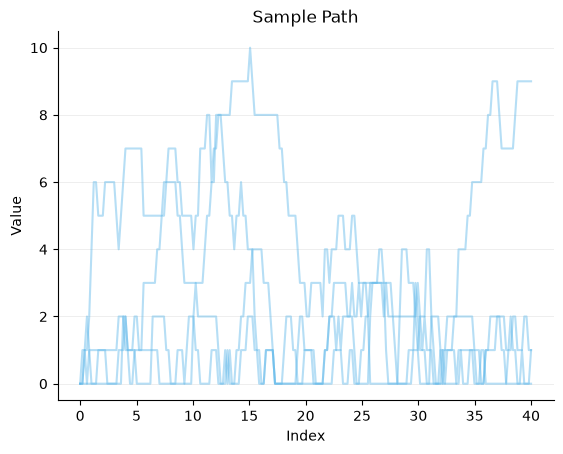

In [35]:
X.sim(4).plot(tmin=0, tmax=40)

## `RV(P, interarrival_times)` -- the times between jumps

The same space, read a different way: how long the process waits at each value before
jumping. Each entry is a random variable, so index it and simulate like anything else.

In [36]:
T = RV(P, interarrival_times)
list(T.sim(1))  # the whole sequence of waits, one per state visited

[(0.1414064620449439, 0.03530300207172475, 0.5857282362849205, 0.06806723112631496, 0.33387059936128327, 0.26942293940410317, ...)]

In [37]:
# The queue starts empty, so the first wait is for the first arrival: Exponential(1),
# averaging 1.
T[0].sim(1000).mean()

1.0356155616031015

## `RV(P, arrival_times)` -- the times of the jumps

The running total of those waits: the clock time at which each jump happens.

In [38]:
A = RV(P, arrival_times)
list(A.sim(1))

[(0.3228566363932646, 0.7767851482756336, 1.9766889929296427, 2.505112794817396, 3.1817630521640874, 3.346871160197463, ...)]

## `RV(P, states)` -- the sequence of states

The values the process passes through, ignoring how long it stayed at each. For this queue
the count only ever moves by one, so the sequence steps up and down by one.

In [39]:
S = RV(P, states)
S.draw()

(0, 1, 2, 3, 4, 5, ...)

In [40]:
# The state right after the first jump is a random variable too -- and for a queue that
# starts empty, the first jump is always an arrival.
S[1].sim(100).mean()

1.0

## The four views describe one path

Drawn separately they are independent simulations, but read off a **single** path they line
up: the process sits at `states[k]` for `interarrival_times[k]`, and leaves it at
`arrival_times[k]`.

In [41]:
path = P.draw()

print("state   stays for   until")
for k in range(6):
    print(
        f"{states(path)[k]:>5}   {interarrival_times(path)[k]:>9.2f}   "
        f"{arrival_times(path)[k]:>5.2f}"
    )

print()
print("the path agrees:", path(arrival_times(path)[0] - 0.01), "just before the first jump,",
      path(arrival_times(path)[0] + 0.01), "just after")

state   stays for   until
    0        0.59    0.59
    1        1.01    1.59
    2        0.56    2.15
    3        1.62    3.77
    4        0.98    4.76
    3        0.19    4.95

the path agrees: 0 just before the first jump, 1 just after


## The same four views, every process

`MM1ProbabilitySpace` was just one example. The same code works for every continuous-time,
discrete-state process in Symbulate -- Markov chains, Poisson and renewal processes,
birth-death processes and all the `M/M/...` queues, Yule processes, the `G/G/1` and `G/G/s`
queues, and the epidemic models.

In [42]:
spaces = {
    "CTMC": ContinuousTimeMarkovChainProbabilitySpace(
        [[-1, 1], [2, -2]], [1.0, 0.0], state_labels=["healthy", "broken"]
    ),
    "Poisson": PoissonProcessProbabilitySpace(rate=2),
    "renewal": RenewalProcessProbabilitySpace(Gamma(shape=2, rate=1)),
    "Yule": YuleProcessProbabilitySpace(birth_rate=0.5),
    "M/M/2": MMsProbabilitySpace(arrival_rate=3, service_rate=2, servers=2),
    "G/G/1": GG1ProbabilitySpace(Uniform(a=0, b=2), Gamma(shape=2, rate=4)),
}

print(f"{'process':<10} {'first states':<48} {'first wait':>10}")
for name, space in spaces.items():
    path = space.draw()
    first_states = str([states(path)[k] for k in range(4)])
    print(f"{name:<10} {first_states:<48} {interarrival_times(path)[0]:>10.2f}")

process    first states                                     first wait
CTMC       ['healthy', 'broken', 'healthy', 'broken']             0.21
Poisson    [0, 1, 2, 3]                                           1.80
renewal    [0, 1, 2, 3]                                           4.90
Yule       [1, 2, 3, 4]                                           0.10
M/M/2      [0, 1, 2, 3]                                           0.13
G/G/1      [0, 1, 2, 1]                                           1.97


The epidemic models are the one family whose state is a whole **vector** of counts -- how
many are susceptible, infected, and recovered -- rather than a single number. The four views
work just the same.

In [43]:
# A contagious outbreak, so it takes off rather than fizzling out immediately.
epidemic = SIRProbabilitySpace(population=50, infection_rate=3, recovery_rate=0.5)
RV(epidemic, states).draw()[:5]  # (S, I, R) after each of the first five events

[(49, 1, 0), (48, 2, 0), (47, 3, 0), (46, 4, 0), (45, 5, 0)]

## The named classes are the same thing

`MM1(...)` and `RV(MM1ProbabilitySpace(...))` are the same process; the class just saves a
step. On a named process the three views are reached with `.apply()`.

In [44]:
queue = MM1(arrival_rate=1, service_rate=1.5, num_states=41)
print("same kind of path:", type(queue.draw()).__name__ == type(RV(P).draw()).__name__)
queue.apply(interarrival_times)[0].sim(1000).mean()  # again the wait for the first arrival

same kind of path: True


1.038740116827039